# 📦 Data Preprocessing — Olist E-Commerce

**Mục tiêu:** Đọc toàn bộ dataset → Lọc & Merge → Xử lý missing → Convert datetime → Tạo target variable → Export `cleaned_orders.csv`

| Bước | Nội dung |
|------|----------|
| 1 | Load tất cả datasets |
| 2 | Lọc chỉ lấy `order_status == delivered` |
| 3 | Merge các bảng |
| 4 | Xử lý missing values |
| 5 | Convert datetime & Feature engineering |
| 6 | Tạo target variable |
| 7 | Export `cleaned_orders.csv` |

## 0. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print(' Libraries imported successfully')
print(f'   Pandas version : {pd.__version__}')
print(f'   NumPy  version : {np.__version__}')

 Libraries imported successfully
   Pandas version : 3.0.2
   NumPy  version : 2.4.4


---
## 1. Load Datasets

In [4]:


ROOT_DIR = os.path.dirname(os.getcwd())

def has_csv(folder):
    return os.path.exists(os.path.join(folder, 'olist_orders_dataset.csv'))

if has_csv(os.path.join(ROOT_DIR, 'archive')):
    DATA_DIR = os.path.join(ROOT_DIR, 'archive')
elif has_csv(os.path.join(ROOT_DIR, 'data', 'raw')):
    DATA_DIR = os.path.join(ROOT_DIR, 'data', 'raw')
else:
    DATA_DIR = os.path.join(os.getcwd(), 'archive')

print(f' DATA_DIR = {DATA_DIR}')

# Load tất cả 6 bảng 
orders    = pd.read_csv(os.path.join(DATA_DIR, 'olist_orders_dataset.csv'))
reviews   = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_reviews_dataset.csv'))
items     = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_items_dataset.csv'))
payments  = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_payments_dataset.csv'))
products  = pd.read_csv(os.path.join(DATA_DIR, 'olist_products_dataset.csv'))
customers = pd.read_csv(os.path.join(DATA_DIR, 'olist_customers_dataset.csv'))

#  Quick shape check 
datasets = {
    'orders'   : orders,
    'reviews'  : reviews,
    'items'    : items,
    'payments' : payments,
    'products' : products,
    'customers': customers,
}

print(' Dataset shapes:')
print('-' * 35)
for name, df in datasets.items():
    print(f'  {name:<12}: {df.shape[0]:>7,} rows × {df.shape[1]:>2} cols')

 DATA_DIR = c:\CODE\CSW439\project_csw439\archive
 Dataset shapes:
-----------------------------------
  orders      :  99,441 rows ×  8 cols
  reviews     :  99,224 rows ×  7 cols
  items       : 112,650 rows ×  7 cols
  payments    : 103,886 rows ×  5 cols
  products    :  32,951 rows ×  9 cols
  customers   :  99,441 rows ×  5 cols


---
## 2. Filter — Chỉ giữ `order_status == 'delivered'`

In [5]:
print(' Phân phối order_status trước khi lọc:')
print(orders['order_status'].value_counts())
print(f'\n  Tổng số đơn hàng: {len(orders):,}')

 Phân phối order_status trước khi lọc:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

  Tổng số đơn hàng: 99,441


In [6]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f' Đơn hàng delivered: {len(orders_delivered):,} '
      f'({len(orders_delivered)/len(orders)*100:.1f}% tổng)')
print(f'   Đã loại bỏ        : {len(orders) - len(orders_delivered):,} đơn hàng')

 Đơn hàng delivered: 96,478 (97.0% tổng)
   Đã loại bỏ        : 2,963 đơn hàng


---
## 3. Merge Các Bảng

Sơ đồ merge:
```
orders_delivered
    ├── LEFT JOIN reviews   ON order_id
    ├── LEFT JOIN items     ON order_id  →  LEFT JOIN products ON product_id
    ├── LEFT JOIN payments  ON order_id  (aggregate: sum & mode)
    └── LEFT JOIN customers ON customer_id
```

> **Lý do dùng LEFT JOIN:** Giữ lại toàn bộ đơn hàng đã delivered, kể cả những đơn chưa có review (xử lý ở bước missing values).

In [7]:
# ── 3a. Xử lý reviews — lấy review mới nhất nếu có duplicate ──────────────
# Một số order có nhiều review → lấy review_score mới nhất
reviews_clean = (
    reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')
    [['order_id', 'review_score', 'review_creation_date', 'review_comment_title',
      'review_comment_message']]
)
print(f'reviews sau khi dedup: {len(reviews_clean):,} rows')

reviews sau khi dedup: 98,673 rows


In [8]:
#  3b. Xử lý items — merge với products, aggregate theo order_id 
# items có thể có nhiều dòng / order (nhiều sản phẩm trong 1 đơn)
items_with_products = items.merge(
    products[['product_id', 'product_category_name',
              'product_weight_g', 'product_length_cm',
              'product_height_cm', 'product_width_cm',
              'product_photos_qty', 'product_description_lenght']],  
    on='product_id',
    how='left'
)

# Aggregate về mức order_id
items_agg = items_with_products.groupby('order_id').agg(
    order_item_count             = ('order_item_id',                'max'),
    total_item_price             = ('price',                        'sum'),
    total_freight_value          = ('freight_value',                'sum'),
    product_category             = ('product_category_name',        lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    avg_product_weight_g         = ('product_weight_g',             'mean'),
    avg_product_length_cm        = ('product_length_cm',            'mean'), 
    avg_product_width_cm         = ('product_width_cm',             'mean'), 
    avg_product_height_cm        = ('product_height_cm',            'mean'),
    avg_product_photos_qty       = ('product_photos_qty',           'mean'), 
    avg_product_description_len  = ('product_description_lenght',   'mean'), 
).reset_index()

print(f'items_agg shape: {items_agg.shape}')

print(f'Columns: {list(items_agg.columns)}')

items_agg shape: (98666, 11)
Columns: ['order_id', 'order_item_count', 'total_item_price', 'total_freight_value', 'product_category', 'avg_product_weight_g', 'avg_product_length_cm', 'avg_product_width_cm', 'avg_product_height_cm', 'avg_product_photos_qty', 'avg_product_description_len']


In [9]:
#  3c. Xử lý payments — aggregate theo order_id 
payments_agg = payments.groupby('order_id').agg(
    payment_type         = ('payment_type',         lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    payment_installments = ('payment_installments',  'max'),
    total_payment_value  = ('payment_value',          'sum'),
).reset_index()

print(f'payments_agg shape: {payments_agg.shape}')

payments_agg shape: (99440, 4)


In [10]:
#  3d. Merge tất cả lại
df = (
    orders_delivered
    .merge(reviews_clean,  on='order_id',   how='left')
    .merge(items_agg,      on='order_id',   how='left')
    .merge(payments_agg,   on='order_id',   how='left')
    .merge(customers,      on='customer_id', how='left')
)

print(f' Merged DataFrame shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')

 Merged DataFrame shape: (96478, 29)
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score', 'review_creation_date', 'review_comment_title', 'review_comment_message', 'order_item_count', 'total_item_price', 'total_freight_value', 'product_category', 'avg_product_weight_g', 'avg_product_length_cm', 'avg_product_width_cm', 'avg_product_height_cm', 'avg_product_photos_qty', 'avg_product_description_len', 'payment_type', 'payment_installments', 'total_payment_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [11]:
df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_creation_date,review_comment_title,review_comment_message,order_item_count,total_item_price,total_freight_value,product_category,avg_product_weight_g,avg_product_length_cm,avg_product_width_cm,avg_product_height_cm,avg_product_photos_qty,avg_product_description_len,payment_type,payment_installments,total_payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,4.00,2017-10-11 00:00:00,NaN,"Não testei o produto ainda, mas ele veio corre...",1,29.99,8.72,utilidades_domesticas,500.00,19.00,13.00,8.00,4.00,268.00,voucher,1.00,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,4.00,2018-08-08 00:00:00,Muito boa a loja,Muito bom o produto.,1,118.70,22.76,perfumaria,400.00,19.00,19.00,13.00,1.00,178.00,boleto,1.00,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,5.00,2018-08-18 00:00:00,NaN,NaN,1,159.90,19.22,automotivo,420.00,24.00,21.00,19.00,1.00,232.00,credit_card,3.00,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


---
## 4. Xử Lý Missing Values

In [12]:
#  4a. Kiểm tra missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct,
    'Dtype'        : df.dtypes
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(' Missing Values Report:')
print(missing_report.to_string())

 Missing Values Report:
                               Missing Count  Missing %    Dtype
review_comment_title                   85286      88.40      str
review_comment_message                 57576      59.68      str
avg_product_description_len             1332       1.38  float64
product_category                        1332       1.38      str
avg_product_photos_qty                  1332       1.38  float64
review_score                             646       0.67  float64
review_creation_date                     646       0.67      str
avg_product_height_cm                     16       0.02  float64
avg_product_weight_g                      16       0.02  float64
avg_product_width_cm                      16       0.02  float64
avg_product_length_cm                     16       0.02  float64
order_approved_at                         14       0.01      str
order_delivered_customer_date              8       0.01      str
order_delivered_carrier_date               2       0.00      str
p

In [13]:
# 4b. Xử lý từng nhóm cột

# [1] review_score: đơn hàng delivered nhưng chưa có review → fillna = -1 (unknown)
#     Cột này quan trọng → KHÔNG drop, đánh dấu riêng
df['has_review'] = df['review_score'].notna().astype(int)
# Các đơn không có review sẽ bị loại khỏi tập train (target = NaN)
# nhưng giữ lại để thống kê

# [2] review_comment: text, fillna = chuỗi rỗng
df['review_comment_title']   = df['review_comment_title'].fillna('')
df['review_comment_message'] = df['review_comment_message'].fillna('')

# [3] order_approved_at: rất ít null → fill bằng order_purchase_timestamp
df['order_approved_at'] = df['order_approved_at'].fillna(df['order_purchase_timestamp'])

# [4] product_category: fill bằng 'unknown'
df['product_category'] = df['product_category'].fillna('unknown')

# [5] avg_product_weight_g: fill bằng median
product_numeric_cols = ['avg_product_weight_g', 'avg_product_length_cm',
                         'avg_product_width_cm', 'avg_product_height_cm',
                         'avg_product_photos_qty', 'avg_product_description_len']
for col in product_numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# [6] payment_type: fill bằng 'unknown'
df['payment_type'] = df['payment_type'].fillna('unknown')

# [7] Các cột payment/item numeric còn lại: fill = 0
numeric_fill_zero = ['payment_installments', 'total_payment_value',
                     'total_item_price', 'total_freight_value', 'order_item_count']
for col in numeric_fill_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# [8] customer_state / city: dropna vì không thể impute địa lý
df = df.dropna(subset=['customer_state'])

print(' Missing values đã xử lý xong!')
remaining_missing = df.isnull().sum()
print(f'   Cột còn missing (ngoài review_score): '
      f'{remaining_missing[remaining_missing > 0 ].drop("review_score", errors="ignore").sum()} cells')

 Missing values đã xử lý xong!
   Cột còn missing (ngoài review_score): 656 cells


In [14]:
# ── 4c. Loại bỏ duplicate order_id ────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset='order_id', keep='first')
print(f'  Duplicate orders removed: {before - len(df)}')
print(f'   DataFrame shape sau dedup: {df.shape}')

  Duplicate orders removed: 0
   DataFrame shape sau dedup: (96478, 30)


---
## 5. Convert Datetime & Feature Engineering

> **💡 Đề xuất thêm:** Tạo các feature thời gian hữu ích cho model sau này:
> - `delivery_days` — số ngày giao thực tế
> - `delay_days` — số ngày trễ so với dự kiến (âm = giao sớm)
> - `approval_time_hours` — thời gian approve đơn hàng
> - `purchase_month`, `purchase_dayofweek` — seasonal patterns

In [15]:
# ── 5a. Convert tất cả cột datetime ───────────────────────────────────────
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
]

for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print(' Datetime columns converted:')
for col in datetime_cols:
    if col in df.columns:
        print(f'   {col:<40}: {df[col].dtype}')

 Datetime columns converted:
   order_purchase_timestamp                : datetime64[us]
   order_approved_at                       : datetime64[us]
   order_delivered_carrier_date            : datetime64[us]
   order_delivered_customer_date           : datetime64[us]
   order_estimated_delivery_date           : datetime64[us]
   review_creation_date                    : datetime64[us]


In [16]:
# ── 5b. Feature engineering từ datetime ───────────────────────────────────

# Số ngày giao thực tế (từ lúc mua đến lúc nhận)
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Số ngày trễ/sớm so với estimated (dương = trễ, âm = giao sớm)
df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# Giờ approve đơn hàng
df['approval_time_hours'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.total_seconds() / 3600

# Seasonal features từ thời điểm mua
df['purchase_month']      = df['order_purchase_timestamp'].dt.month
df['purchase_dayofweek']  = df['order_purchase_timestamp'].dt.dayofweek  # 0=Mon, 6=Sun
df['purchase_hour']       = df['order_purchase_timestamp'].dt.hour
df['purchase_year']       = df['order_purchase_timestamp'].dt.year

# Clip outliers cho delivery_days và delay_days (nếu có giá trị âm vô lý)
df['delivery_days'] = df['delivery_days'].clip(lower=0)

print(' Feature engineering hoàn tất!')
new_features = ['delivery_days', 'delay_days', 'approval_time_hours',
                'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'purchase_year']
print(df[new_features].describe().round(2))

 Feature engineering hoàn tất!
       delivery_days  delay_days  approval_time_hours  purchase_month  \
count       96470.00    96470.00             96478.00        96478.00   
mean           12.09      -11.88                10.28            6.03   
std             9.55       10.18                20.53            3.23   
min             0.00     -147.00                 0.00            1.00   
25%             6.00      -17.00                 0.22            3.00   
50%            10.00      -12.00                 0.34            6.00   
75%            15.00       -7.00                14.51            8.00   
max           209.00      188.00               741.44           12.00   

       purchase_dayofweek  purchase_hour  purchase_year  
count            96478.00       96478.00       96478.00  
mean                 2.76          14.77        2017.54  
std                  1.97           5.33           0.50  
min                  0.00           0.00        2016.00  
25%                  

---
## 6. Tạo Target Variable

| review_score | target | Ý nghĩa |
|:---:|:---:|---|
| 1, 2, 3 | **0** | Khách hàng không hài lòng |
| 4, 5    | **1** | Khách hàng hài lòng |

In [17]:
# Tạo target variable
df['target'] = df['review_score'].apply(
    lambda x: 1 if x >= 4 else (0 if x <= 3 else np.nan)
)

print(' Phân phối target variable:')
target_dist = df['target'].value_counts(dropna=False)
for val, count in target_dist.items():
    pct = count / len(df) * 100
    label = ' Hài lòng (1)' if val == 1 else (' Không hài lòng (0)' if val == 0 else ' Chưa có review (NaN)')
    print(f'   {label}: {count:,} ({pct:.1f}%)')

# Tỉ lệ class imbalance
valid = df['target'].dropna()
ratio = valid.value_counts(normalize=True)
print(f'\n   Class ratio (0:1) = {ratio[0]:.2f} : {ratio[1]:.2f}')
if ratio[1] > 0.7:
    print('   Class imbalance khá cao — cân nhắc dùng SMOTE hoặc class_weight khi train!')

 Phân phối target variable:
    Hài lòng (1): 75,644 (78.4%)
    Không hài lòng (0): 20,188 (20.9%)
    Chưa có review (NaN): 646 (0.7%)

   Class ratio (0:1) = 0.21 : 0.79
   Class imbalance khá cao — cân nhắc dùng SMOTE hoặc class_weight khi train!


---
## 7. Final Dataset & Export

In [18]:
# ── 7a. Chọn và sắp xếp các cột output ────────────────────────────────────
FINAL_COLUMNS = [
    # IDs
    'order_id', 'customer_id', 'customer_unique_id',

    # Order info
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',

    # Time features
    'delivery_days',
    'delay_days',
    'approval_time_hours',
    'purchase_year',
    'purchase_month',
    'purchase_dayofweek',
    'purchase_hour',

    # Items / Products
    'order_item_count',
    'product_category',
    'avg_product_weight_g',
     'avg_product_length_cm',       
    'avg_product_width_cm',       
    'avg_product_height_cm',      
    'avg_product_photos_qty',      
    'avg_product_description_len',  
    'total_item_price',
    'total_freight_value',

    # Payments
    'payment_type',
    'payment_installments',
    'total_payment_value',

    # Customer location
    'customer_city',
    'customer_state',
    'customer_zip_code_prefix',

    # Review
    'review_score',
    'has_review',
    'review_comment_title',
    'review_comment_message',
    'review_creation_date',

    # TARGET
    'target',
]

final_columns = [c for c in FINAL_COLUMNS if c in df.columns]
final_df = df[final_columns].copy()

print(f' Final DataFrame: {final_df.shape[0]:,} rows × {final_df.shape[1]} cols')

 Final DataFrame: 96,478 rows × 38 cols


In [19]:
#  7b. Summary report
print('=' * 55)
print('           📦 PREPROCESSING SUMMARY REPORT')
print('=' * 55)
print(f'  Total delivered orders        : {len(final_df):>8,}')
print(f'  Orders có review (trainable)  : {final_df["target"].notna().sum():>8,}')
print(f'  Orders không có review        : {final_df["target"].isna().sum():>8,}')
print(f'  Target = 1 (hài lòng)         : {(final_df["target"]==1).sum():>8,}')
print(f'  Target = 0 (không hài lòng)   : {(final_df["target"]==0).sum():>8,}')
print(f'  Avg delivery days             : {final_df["delivery_days"].mean():>8.1f} ngày')
print(f'  Avg delay days                : {final_df["delay_days"].mean():>8.1f} ngày')
print(f'  Avg total payment value       : {final_df["total_payment_value"].mean():>8.2f}')
print('=' * 55)

           📦 PREPROCESSING SUMMARY REPORT
  Total delivered orders        :   96,478
  Orders có review (trainable)  :   95,832
  Orders không có review        :      646
  Target = 1 (hài lòng)         :   75,644
  Target = 0 (không hài lòng)   :   20,188
  Avg delivery days             :     12.1 ngày
  Avg delay days                :    -11.9 ngày
  Avg total payment value       :   159.85


In [20]:
# ── 7c. Export CSV ─────────────────────────────────────────────────────────
OUTPUT_PATH = os.path.join(os.getcwd(), 'cleaned_orders.csv')
final_df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')

file_size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f' Exported: cleaned_orders.csv')
print(f'   Path    : {OUTPUT_PATH}')
print(f'   Size    : {file_size_mb:.2f} MB')
print(f'   Rows    : {len(final_df):,}')
print(f'   Columns : {final_df.shape[1]}')

 Exported: cleaned_orders.csv
   Path    : c:\CODE\CSW439\project_csw439\notebooks\cleaned_orders.csv
   Size    : 37.15 MB
   Rows    : 96,478
   Columns : 38


In [21]:
#  7d. Preview final output 
final_df.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,approval_time_hours,purchase_year,purchase_month,purchase_dayofweek,purchase_hour,order_item_count,product_category,avg_product_weight_g,avg_product_length_cm,avg_product_width_cm,avg_product_height_cm,avg_product_photos_qty,avg_product_description_len,total_item_price,total_freight_value,payment_type,payment_installments,total_payment_value,customer_city,customer_state,customer_zip_code_prefix,review_score,has_review,review_comment_title,review_comment_message,review_creation_date,target
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.00,-8.00,0.18,2017,10,0,10,1,utilidades_domesticas,500.00,19.00,13.00,8.00,4.00,268.00,29.99,8.72,voucher,1.00,38.71,sao paulo,SP,3149,4.00,1,,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,1.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.00,-6.00,30.71,2018,7,1,20,1,perfumaria,400.00,19.00,19.00,13.00,1.00,178.00,118.70,22.76,boleto,1.00,141.46,barreiras,BA,47813,4.00,1,Muito boa a loja,Muito bom o produto.,2018-08-08,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.00,-18.00,0.28,2018,8,2,8,1,automotivo,420.00,24.00,21.00,19.00,1.00,232.00,159.90,19.22,credit_card,3.00,179.12,vianopolis,GO,75265,5.00,1,,,2018-08-18,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.00,-13.00,0.30,2017,11,5,19,1,pet_shop,450.00,30.00,20.00,10.00,3.00,468.00,45.00,27.20,credit_card,1.00,72.20,sao goncalo do amarante,RN,59296,5.00,1,,O produto foi exatamente o que eu esperava e e...,2017-12-03,1.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.00,-10.00,1.03,2018,2,1,21,1,papelaria,250.00,51.00,15.00,15.00,4.00,316.00,19.90,8.72,credit_card,1.00,28.62,santo andre,SP,9195,5.00,1,,,2018-02-17,1.00


In [22]:
#  7e. Kiểm tra data types của file export 
print('Column dtypes trong cleaned_orders.csv:')
print(final_df.dtypes.to_string())

Column dtypes trong cleaned_orders.csv:
order_id                                    str
customer_id                                 str
customer_unique_id                          str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
delivery_days                           float64
delay_days                              float64
approval_time_hours                     float64
purchase_year                             int32
purchase_month                            int32
purchase_dayofweek                        int32
purchase_hour                             int32
order_item_count                          int64
product_category                            str
avg_product_weight_g                    float64
avg_product_length_cm                   float64


---
## 8. (Bonus) Quick EDA — Kiểm tra chất lượng data

> ** Đề xuất:** Chạy cell này để verify data trước khi chuyển cho các thành viên khác.

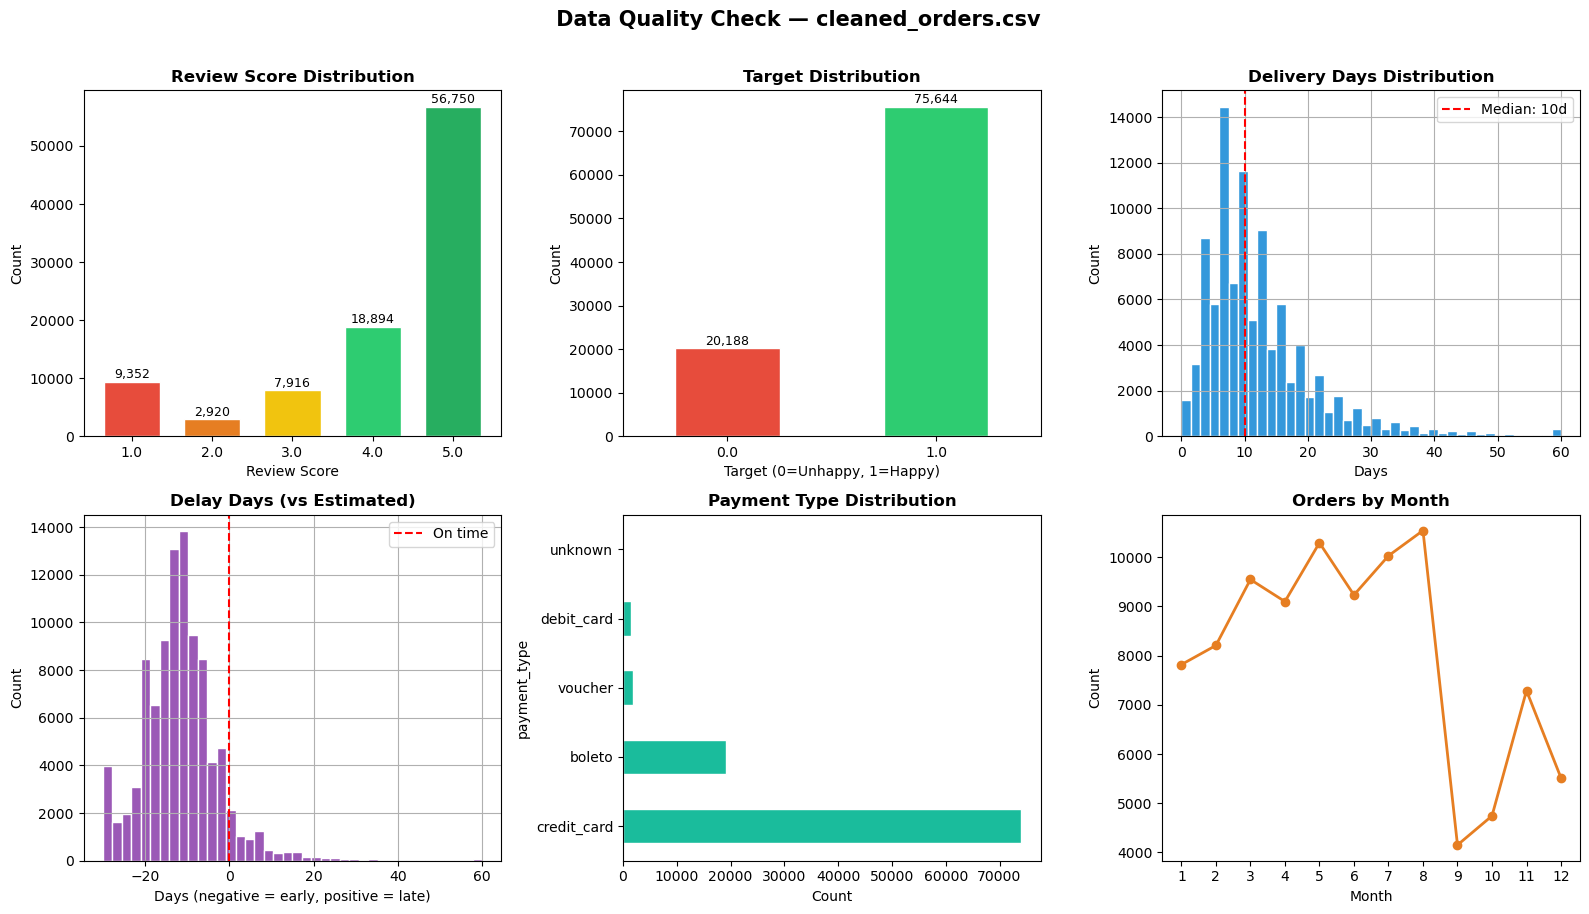

 EDA chart saved: preprocessing_eda.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(' Data Quality Check — cleaned_orders.csv', fontsize=15, fontweight='bold', y=1.01)

# 1. Review score distribution
ax = axes[0, 0]
score_counts = final_df['review_score'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
score_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.7)
ax.set_title('Review Score Distribution', fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# 2. Target distribution
ax = axes[0, 1]
target_counts = final_df['target'].value_counts().sort_index()
target_counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
ax.set_title('Target Distribution', fontweight='bold')
ax.set_xlabel('Target (0=Unhappy, 1=Happy)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# 3. Delivery days distribution
ax = axes[0, 2]
final_df['delivery_days'].clip(0, 60).hist(bins=40, ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Delivery Days Distribution', fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Count')
ax.axvline(final_df['delivery_days'].median(), color='red', linestyle='--', label=f'Median: {final_df["delivery_days"].median():.0f}d')
ax.legend()

# 4. Delay days distribution
ax = axes[1, 0]
final_df['delay_days'].clip(-30, 60).hist(bins=40, ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Delay Days (vs Estimated)', fontweight='bold')
ax.set_xlabel('Days (negative = early, positive = late)')
ax.set_ylabel('Count')
ax.axvline(0, color='red', linestyle='--', label='On time')
ax.legend()

# 5. Payment type
ax = axes[1, 1]
pay_counts = final_df['payment_type'].value_counts()
pay_counts.plot(kind='barh', ax=ax, color='#1abc9c', edgecolor='white')
ax.set_title('Payment Type Distribution', fontweight='bold')
ax.set_xlabel('Count')

# 6. Purchase month
ax = axes[1, 2]
month_counts = final_df['purchase_month'].value_counts().sort_index()
month_counts.plot(kind='line', ax=ax, color='#e67e22', marker='o', linewidth=2)
ax.set_title('Orders by Month', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('preprocessing_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(' EDA chart saved: preprocessing_eda.png')

---
##  Done!

**File output:**
- `cleaned_orders.csv` — dataset sạch, mỗi dòng = 1 đơn hàng delivered

**Các thành viên khác đọc file này như sau:**
```python
import pandas as pd

df = pd.read_csv('cleaned_orders.csv', parse_dates=[
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'review_creation_date'
])

# Lọc chỉ lấy rows có label (có review)
df_labeled = df[df['target'].notna()].copy()
```

**Các cột quan trọng cho model:**

| Cột | Loại | Ý nghĩa |
|-----|------|----------|
| `target` | int (0/1) | Label chính — hài lòng hay không |
| `delivery_days` | float | Số ngày giao thực tế |
| `delay_days` | float | Giao trễ/sớm so với dự kiến |
| `total_payment_value` | float | Giá trị đơn hàng |
| `payment_type` | str | Phương thức thanh toán |
| `product_category` | str | Danh mục sản phẩm |
| `customer_state` | str | Bang của khách hàng |
| `order_item_count` | int | Số sản phẩm trong đơn |
| `avg_product_length_cm` | float | Chiều dài TB sản phẩm → tính volume |
| `avg_product_width_cm` | float | Chiều rộng TB sản phẩm → tính volume |
| `avg_product_height_cm` | float | Chiều cao TB sản phẩm → tính volume |
| `avg_product_photos_qty` | float | Số ảnh TB → product info score |
| `avg_product_description_len` | float | Độ dài mô tả TB → product info score |